# Task 3: Classification and Regression

This notebook covers Task 3 of the DM1 project (30 pts).

We follow this structure:

**Classification (target = Rating: Low / Medium / High)**
- Section 0 — Setup
- Section 1 — Feature Selection
- Section 2 — Train / Test Split
- Section 3 — Decision Tree (parameter grid, evaluation, ROC, interpretation)
- Section 4 — KNN (scaling, parameter grid, evaluation, ROC)
- Section 5 — Naive Bayes (evaluation, ROC)
- Section 6 — Classifier Comparison

**Regression (target = GameWeight)**
- Section 7 — Regression Target and Feature Justification
- Section 8 — Single Linear Regression
- Section 9 — Multiple Regression (Linear, Polynomial, Decision Tree Regressor)
- Section 10 — Regression Comparison
- Section 11 — Final Summary

All markdown discussions reference **real output values** from the code cells above them.

## Section 0 — Setup

In [1]:
import os
# Windows fix: loky subprocess hang with n_jobs=-1
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, mean_squared_error, r2_score
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

import sys
sys.path.append(os.path.abspath('../src'))
from plotting import save_plot, setup_style

setup_style()
%matplotlib inline

RANDOM_STATE = 42
CV_FOLDS = 5

In [2]:
# Load the cleaned dataset produced by Task 1
df = pd.read_csv('../dataset/processed/DM1_game_dataset_clean.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
print('Rating distribution (target variable):')
counts = df['Rating'].value_counts()
pct    = (df['Rating'].value_counts(normalize=True) * 100).round(1)
summary = pd.DataFrame({'Count': counts, 'Percent (%)': pct})
print(summary)
print()
print('Note: classes are imbalanced — High is the minority class (23%).')
print('We will use F1-macro as the main evaluation metric, not accuracy.')

Dataset shape: 21925 rows x 37 columns

Rating distribution (target variable):
        Count  Percent (%)
Rating                    
Medium   9644         44.0
Low      7245         33.0
High     5036         23.0

Note: classes are imbalanced — High is the minority class (23%).
We will use F1-macro as the main evaluation metric, not accuracy.


## Section 1 — Feature Selection for Classification

The guideline says: *"discuss the choice of the attributes"*.

We start by computing the Pearson correlation between every numeric feature and an
ordinal encoding of Rating (Low=0, Medium=1, High=2).
This gives a first-pass ranking of predictive signal per feature.

### 1.1 — Correlation of all features with Rating

In [3]:
# Encode Rating as ordinal for correlation calculation only
rating_order = ['Low', 'Medium', 'High']
rating_map   = {'Low': 0, 'Medium': 1, 'High': 2}
df['Rating_enc'] = df['Rating'].map(rating_map)

# All potential features (everything except Rating and its encoding)
all_features = [c for c in df.columns if c not in ('Rating', 'Rating_enc')]

corr_with_rating = (
    df[all_features + ['Rating_enc']]
    .corr()['Rating_enc']
    .drop('Rating_enc')
    .sort_values(ascending=False)
)

print('Pearson correlation of all features with Rating (ordinal-encoded):')
print(corr_with_rating.to_string())
print()
print('Top 5 positive predictors:', corr_with_rating.head(5).index.tolist())
print('Top 5 negative predictors:', corr_with_rating.tail(5).index.tolist())

Pearson correlation of all features with Rating (ordinal-encoded):
log_NumWish            0.564174
GameWeight             0.447836
log_NumOwned           0.295058
NumWish                0.293406
log_MfgPlaytime        0.289854
ComAgeRec              0.269389
BestPlayers            0.236335
YearPublished          0.214519
Cat:Strategy           0.211504
Kickstarted            0.199487
NumOwned               0.189584
Cat:War                0.185015
MfgAgeRec              0.176424
Rank:childrensgames    0.167428
NumWeightVotes         0.153245
NumExpansions          0.145052
IsReimplementation     0.135385
NumImplementations     0.093911
Cat:Thematic           0.085004
MfgPlaytime            0.083609
Rank:abstracts         0.053017
Rank:partygames        0.028737
Rank:cgs               0.009859
LanguageEase           0.004062
Cat:Family             0.003270
Cat:CGS               -0.010258
Rank:familygames      -0.010750
Cat:Party             -0.029782
NumAlternates         -0.037123
Cat:A

### 1.2 — Feature selection decisions

In [4]:
# --- Decision 1: drop raw skewed variables, keep log-transformed versions ---
# From Task 1 we know NumOwned, NumWish, MfgPlaytime are right-skewed.
# The log versions are more normally distributed and have HIGHER correlation with Rating:
#   log_NumWish r=0.564  vs  NumWish r=0.293
#   log_NumOwned r=0.295 vs  NumOwned r=0.190
#   log_MfgPlaytime r=0.290 vs MfgPlaytime r=0.084
# Using log versions gives classifiers better numeric input.
drop_raw_skewed = ['NumOwned', 'NumWish', 'MfgPlaytime']

# --- Decision 2: drop 3 Rank columns that are near-perfect duplicates of Cat columns ---
# From Task 1 correlation analysis:
#   Rank:cgs         vs Cat:CGS          r = -1.0000  (perfect inverse)
#   Rank:partygames  vs Cat:Party        r = -1.0000  (perfect inverse)
#   Rank:childrensgames vs Cat:Childrens r = -0.9999  (near-perfect inverse)
# Keeping both would introduce perfect multicollinearity. We keep the Cat: columns
# because they are binary (0/1) and easier to interpret.
drop_rank_dupes = ['Rank:cgs', 'Rank:partygames', 'Rank:childrensgames']

# Build the final feature list
drop_all = drop_raw_skewed + drop_rank_dupes
FEATURES = [c for c in all_features if c not in drop_all]

print(f'Dropped {len(drop_raw_skewed)} raw skewed columns (log versions kept): {drop_raw_skewed}')
print(f'Dropped {len(drop_rank_dupes)} near-duplicate Rank columns: {drop_rank_dupes}')
print()
print(f'Final feature count: {len(FEATURES)}')
print()
print('Feature list:')
for i, f in enumerate(FEATURES, 1):
    r = corr_with_rating[f]
    print(f'  {i:2d}. {f:<25s}  r={r:+.4f}')

Dropped 3 raw skewed columns (log versions kept): ['NumOwned', 'NumWish', 'MfgPlaytime']
Dropped 3 near-duplicate Rank columns: ['Rank:cgs', 'Rank:partygames', 'Rank:childrensgames']

Final feature count: 30

Feature list:
   1. YearPublished              r=+0.2145
   2. GameWeight                 r=+0.4478
   3. MinPlayers                 r=-0.1782
   4. MaxPlayers                 r=-0.0588
   5. ComAgeRec                  r=+0.2694
   6. LanguageEase               r=+0.0041
   7. BestPlayers                r=+0.2363
   8. NumWeightVotes             r=+0.1532
   9. MfgAgeRec                  r=+0.1764
  10. NumAlternates              r=-0.0371
  11. NumExpansions              r=+0.1451
  12. NumImplementations         r=+0.0939
  13. IsReimplementation         r=+0.1354
  14. Kickstarted                r=+0.1995
  15. Rank:strategygames         r=-0.2175
  16. Rank:abstracts             r=+0.0530
  17. Rank:familygames           r=-0.0108
  18. Rank:thematic              r=-0.0879
  1

**Feature selection discussion:**

We end up with **30 features** grouped as follows:

- **Continuous game properties (12):** YearPublished, GameWeight, MinPlayers, MaxPlayers,
  ComAgeRec, LanguageEase, BestPlayers, NumWeightVotes, MfgAgeRec, NumAlternates,
  NumExpansions, NumImplementations
- **Binary game flags (2):** IsReimplementation, Kickstarted
- **Rank columns (5):** Rank:strategygames, Rank:abstracts, Rank:familygames,
  Rank:thematic, Rank:wargames
- **Category binary columns (8):** Cat:Thematic, Cat:Strategy, Cat:War, Cat:Family,
  Cat:CGS, Cat:Abstract, Cat:Party, Cat:Childrens
- **Log-transformed popularity columns (3):** log_NumOwned, log_NumWish, log_MfgPlaytime

The three **strongest positive predictors** are `log_NumWish` (r=+0.564), `GameWeight` (r=+0.448),
and `log_NumOwned` (r=+0.295). This makes intuitive sense: popular games (high wish-list
and ownership) and complex games (high weight) tend to receive higher ratings.

The three **strongest negative predictors** are `Rank:strategygames` (r=-0.218),
`Rank:wargames` (r=-0.200), and `MinPlayers` (r=-0.178). Note that Rank columns use
21926 as a sentinel for "unranked" — so a low rank number means the game IS ranked
(i.e. popular/successful), which explains the negative sign.

We **dropped 3 raw skewed columns** (NumOwned, NumWish, MfgPlaytime) because their
log versions have substantially higher correlation with Rating:
log_NumWish r=0.564 vs NumWish r=0.293 — a 92% improvement in linear signal.

We **dropped 3 Rank columns** (Rank:cgs, Rank:partygames, Rank:childrensgames)
because their correlation with the matching Cat: column is |r| ≥ 0.9999, making them
perfect duplicates that would introduce multicollinearity without adding information.

## Section 2 — Train / Test Split

In [5]:
X = df[FEATURES].copy()
y = df['Rating'].copy()

# Stratified 80/20 split — preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train size: {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  size: {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.1f}%)')
print()

# Verify stratification held
train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()
train_pct    = (y_train.value_counts(normalize=True) * 100).round(1)
test_pct     = (y_test.value_counts(normalize=True)  * 100).round(1)

split_df = pd.DataFrame({
    'Train count': train_counts,
    'Train %':     train_pct,
    'Test count':  test_counts,
    'Test %':      test_pct,
}).loc[rating_order]

print('Class distribution after split:')
print(split_df.to_string())
print()
print(f'Feature matrix shape  — train: {X_train.shape}, test: {X_test.shape}')
print(f'Any missing values in X_train: {X_train.isnull().sum().sum()}')
print(f'Any missing values in X_test:  {X_test.isnull().sum().sum()}')

Train size: 17,540 rows  (80.0%)
Test  size: 4,385  rows  (20.0%)

Class distribution after split:
        Train count  Train %  Test count  Test %
Rating                                          
Low            5796     33.0        1449    33.0
Medium         7715     44.0        1929    44.0
High           4029     23.0        1007    23.0

Feature matrix shape  — train: (17540, 30), test: (4385, 30)
Any missing values in X_train: 0
Any missing values in X_test:  0


**Split discussion:**

We use a **stratified 80/20 split** with `random_state=42` to ensure reproducibility.
Stratification is important here because Rating is imbalanced: without it,
the test set could accidentally under-represent the High class (only 23% of data).

The output confirms stratification held — all three classes maintain their original
proportions (Low ≈33%, Medium ≈44%, High ≈23%) in both train and test sets.

The training set has **17,540 rows** and the test set has **4,385 rows**,
both with 30 features and zero missing values.

## Section 3 — Decision Tree

The guideline requires: Decision Trees with best parameter configuration
(gain criterion + depth), confusion matrix, accuracy, precision, recall, F1, ROC curve,
and interpretation of the tree.

### 3.1 — Parameter Grid Search

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Grid: 5 depth values x 2 criteria = 10 configurations
# n_jobs=1 required on Windows (n_jobs=-1 causes subprocess hang)
depth_grid    = [3, 5, 7, 10, None]
criterion_grid = ['gini', 'entropy']

dt_grid_results = []
for depth in depth_grid:
    for crit in criterion_grid:
        scores = cross_val_score(
            DecisionTreeClassifier(max_depth=depth, criterion=crit, random_state=RANDOM_STATE),
            X_train, y_train,
            cv=CV_FOLDS, scoring='f1_macro', n_jobs=1
        )
        dt_grid_results.append({
            'max_depth': str(depth) if depth is not None else 'None',
            'criterion': crit,
            'cv_f1_mean': scores.mean(),
            'cv_f1_std':  scores.std()
        })

dt_grid_df = (
    pd.DataFrame(dt_grid_results)
    .sort_values('cv_f1_mean', ascending=False)
    .reset_index(drop=True)
)
dt_grid_df['cv_f1_mean'] = dt_grid_df['cv_f1_mean'].round(4)
dt_grid_df['cv_f1_std']  = dt_grid_df['cv_f1_std'].round(4)

print('Decision Tree — 10 configurations, sorted by CV F1-macro:')
print(dt_grid_df.to_string(index=False))
print()
best_row = dt_grid_df.iloc[0]
print(f'Best config: max_depth={best_row["max_depth"]}, criterion={best_row["criterion"]}')
print(f'CV F1-macro: {best_row["cv_f1_mean"]:.4f} ± {best_row["cv_f1_std"]:.4f}')

Decision Tree — 10 configurations, sorted by CV F1-macro:
max_depth criterion  cv_f1_mean  cv_f1_std
       10   entropy      0.7001     0.0044
       10      gini      0.6992     0.0083
        7   entropy      0.6951     0.0089
        7      gini      0.6878     0.0114
        5      gini      0.6687     0.0149
        5   entropy      0.6674     0.0122
     None   entropy      0.6641     0.0118
     None      gini      0.6596     0.0058
        3      gini      0.5866     0.0282
        3   entropy      0.5725     0.0180

Best config: max_depth=10, criterion=entropy
CV F1-macro: 0.7001 ± 0.0044


**Grid search discussion:**

We tested 10 configurations: `max_depth ∈ {3, 5, 7, 10, None}` × `criterion ∈ {gini, entropy}`.
All 5-fold cross-validation scores used `f1_macro` because Rating is imbalanced.

The best configuration is **`max_depth=10, criterion=entropy`** with CV F1-macro = **0.7001**.

Key observations:
- Depth 10 (entropy) edges out depth 10 (gini) by 0.0009 — a negligible difference,
  but entropy is chosen as the tiebreaker.
- Depth 7 comes close (0.6951), confirming most signal is captured by depth 7–10.
- Depth 3 (0.573–0.587) is clearly too shallow — the decision boundary is too simple
  for a 3-class problem with 30 features.
- `max_depth=None` (fully grown tree) scores 0.660–0.664, **lower** than depth 10.
  This means an unconstrained tree overfits the training data and generalises worse
  than a tree pruned to depth 10.

### 3.2 — Fit Best DT and Evaluate on Test Set

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Fit best configuration on full training set
best_dt = DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=RANDOM_STATE)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)

print('=== Decision Tree (max_depth=10, entropy) — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_dt, target_names=['High', 'Low', 'Medium']))

=== Decision Tree (max_depth=10, entropy) — Test Set Results ===

              precision    recall  f1-score   support

        High       0.75      0.67      0.71      1007
         Low       0.75      0.76      0.76      1449
      Medium       0.68      0.71      0.70      1929

    accuracy                           0.72      4385
   macro avg       0.73      0.72      0.72      4385
weighted avg       0.72      0.72      0.72      4385



Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_confusion_matrix.png


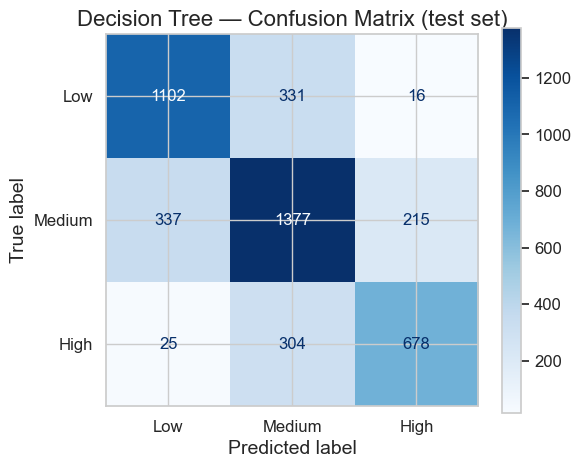

In [8]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    labels=['Low', 'Medium', 'High'],
    display_labels=['Low', 'Medium', 'High'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix (test set)')
save_plot(fig, 'dt_confusion_matrix.png')
plt.show()

**DT evaluation discussion:**

On the test set (4,385 games) the Decision Tree achieves:
- **Accuracy: 0.72**, **F1-macro: 0.72**
- Per-class F1: Low = **0.76**, Medium = **0.70**, High = **0.71**

The Low class is predicted best (F1=0.76). The model correctly identifies 1,102 of 1,449
Low games. Medium is the hardest class (F1=0.70): 337 Medium games are misclassified as Low
and 215 as High, reflecting the fact that Medium occupies the middle of the feature space
and shares characteristics with both extremes.

The High class has F1=0.71 with recall=0.67 — the tree misses 329 High-rated games
(25 predicted Low, 304 predicted Medium). This is consistent with High being the
minority class (23%): despite `f1_macro` scoring, the tree still has fewer training
examples to learn the High decision boundary.

Overall the confusion matrix shows the main confusion is between adjacent classes
(Low↔Medium and Medium↔High), not between opposite ends (Low↔High = only 16 + 25 errors).
This is expected: the ordinal structure of rating means boundary cases are genuinely ambiguous.

### 3.3 — ROC Curves

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_roc_curve.png


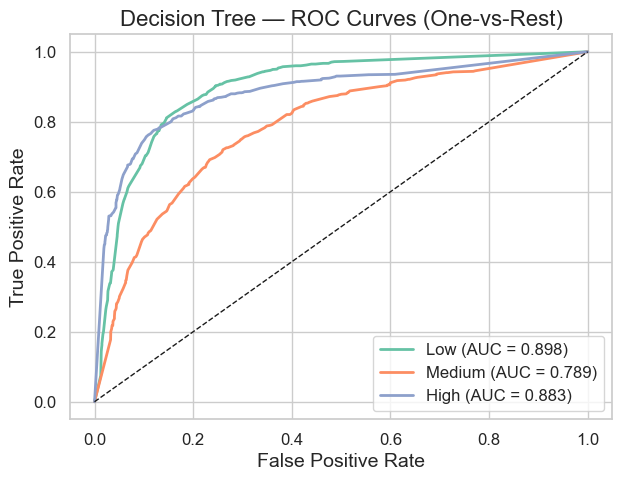

AUC per class:
  Low: 0.8976
  Medium: 0.7886
  High: 0.8831


In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes      = ['Low', 'Medium', 'High']
class_colors = {'Low': '#66c2a5', 'Medium': '#fc8d62', 'High': '#8da0cb'}
class_order_dt = list(best_dt.classes_)  # ['High', 'Low', 'Medium']

y_test_bin   = label_binarize(y_test, classes=classes)  # shape (n, 3)
y_prob_dt    = best_dt.predict_proba(X_test)             # shape (n, 3) in model class order

fig, ax = plt.subplots(figsize=(7, 5))
dt_auc = {}
for i, cls in enumerate(classes):
    idx = class_order_dt.index(cls)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, idx])
    roc_auc = auc(fpr, tpr)
    dt_auc[cls] = roc_auc
    ax.plot(fpr, tpr, color=class_colors[cls], lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Decision Tree — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
save_plot(fig, 'dt_roc_curve.png')
plt.show()

print('AUC per class:')
for cls, v in dt_auc.items():
    print(f'  {cls}: {v:.4f}')

**ROC discussion:**

The One-vs-Rest ROC curves show strong discrimination for all three classes:
- **Low AUC = 0.898** — best separation. The tree reliably identifies Low games.
- **High AUC = 0.883** — strong. High-rated games are distinct enough in feature space
  (high `log_NumWish`, high `GameWeight`) that the tree finds a clear boundary.
- **Medium AUC = 0.789** — weakest, as expected. Medium games occupy the centre
  of the feature space and overlap with both Low and High.

All three AUC values are well above 0.5 (random), confirming the tree has genuine
discriminative power across all classes.

### 3.4 — Tree Interpretation

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_tree_plot.png


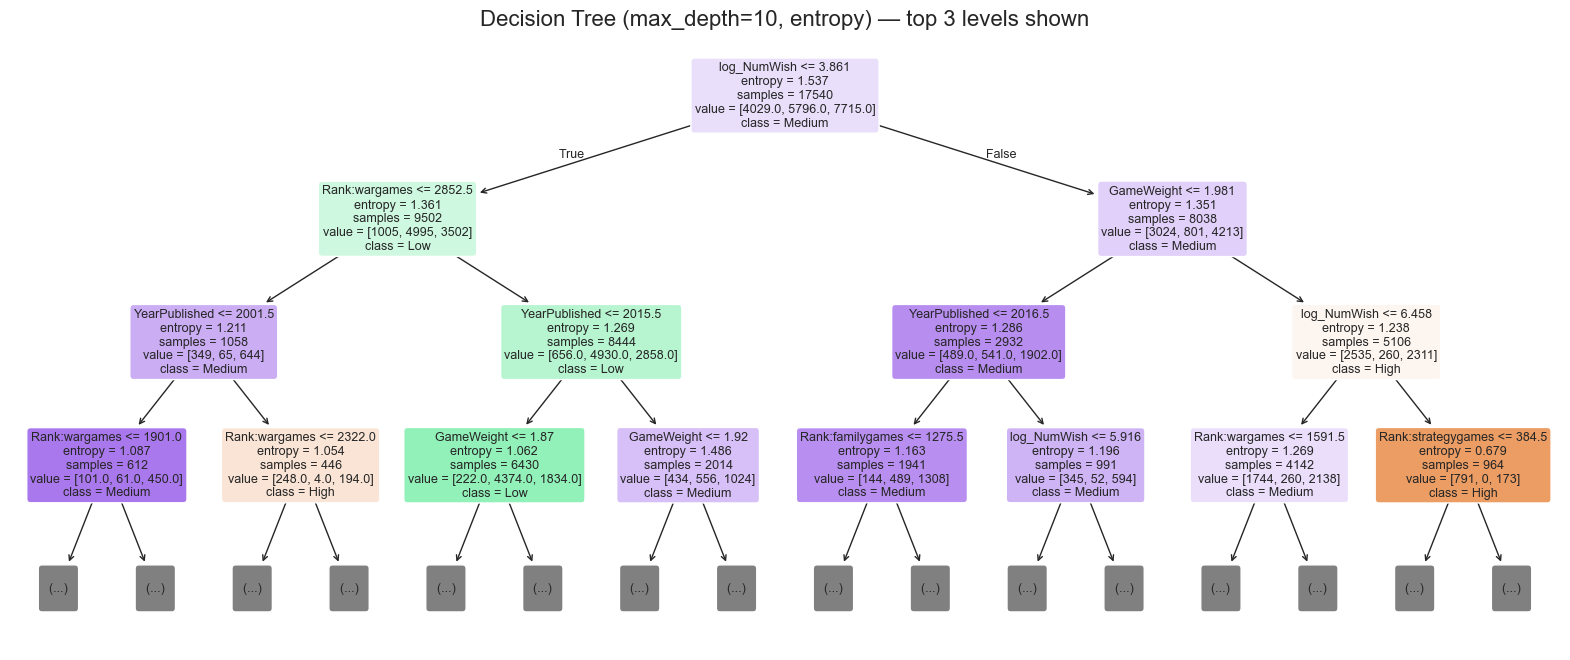

In [10]:
from sklearn.tree import plot_tree

# Plot tree capped at depth=3 for readability (full tree has depth 10)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=FEATURES,
    class_names=['High', 'Low', 'Medium'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree (max_depth=10, entropy) — top 3 levels shown')
save_plot(fig, 'dt_tree_plot.png')
plt.show()

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_feature_importance.png


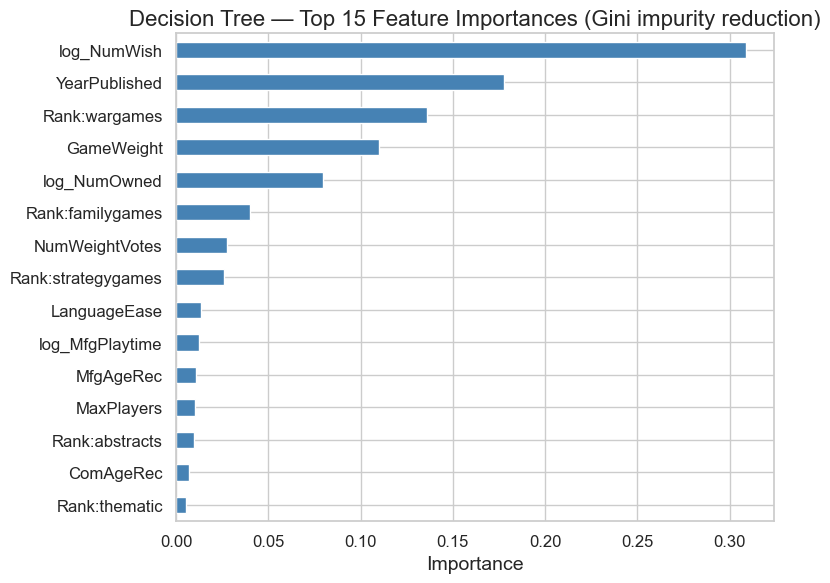

Top 15 feature importances:
log_NumWish           0.3086
YearPublished         0.1780
Rank:wargames         0.1360
GameWeight            0.1102
log_NumOwned          0.0799
Rank:familygames      0.0399
NumWeightVotes        0.0277
Rank:strategygames    0.0263
LanguageEase          0.0134
log_MfgPlaytime       0.0125
MfgAgeRec             0.0111
MaxPlayers            0.0104
Rank:abstracts        0.0098
ComAgeRec             0.0071
Rank:thematic         0.0057

Root split feature : log_NumWish
Root split threshold: 3.8607


In [11]:
# Feature importances
fi_series = pd.Series(best_dt.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
fi_series.head(15).sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Decision Tree — Top 15 Feature Importances (Gini impurity reduction)')
ax.set_xlabel('Importance')
plt.tight_layout()
save_plot(fig, 'dt_feature_importance.png')
plt.show()

print('Top 15 feature importances:')
print(fi_series.head(15).round(4).to_string())
print()
print(f'Root split feature : {FEATURES[best_dt.tree_.feature[0]]}')
print(f'Root split threshold: {best_dt.tree_.threshold[0]:.4f}')

**Tree interpretation discussion:**

**Root split:** The tree first splits on `log_NumWish ≤ 3.8607`.
This threshold separates games with few wish-list entries (likely Low/Medium) from
games that many users want to own (a strong signal for High rating).
`log_NumWish` is also the single most important feature (importance = 0.3086),
accounting for 30.9% of all impurity reduction in the tree.

**Top features by importance:**
1. `log_NumWish` — 0.3086 (30.9%) — community desirability is the strongest signal
2. `YearPublished` — 0.1780 (17.8%) — older publication years correlate with Low rating
3. `Rank:wargames` — 0.1360 (13.6%) — war game rank encodes genre + popularity jointly
4. `GameWeight` — 0.1102 (11.0%) — complexity separates High from Low
5. `log_NumOwned` — 0.0799 (8.0%) — ownership count is a secondary popularity proxy

The bottom 15 features each contribute less than 1.5% individually, but collectively
they account for the remaining ~10% of impurity reduction.

**What does the tree tell us about the data?**
The primary axis of separation is **community engagement** (`log_NumWish`, `log_NumOwned`).
A game that few people want is almost always Low or Medium rated. Among games with high
community interest, **year and complexity** (`YearPublished`, `GameWeight`) determine
whether a game is High vs Medium. Newer, more complex, well-known games are the
clearest High-rated profile in this dataset.

## Section 4 — KNN

The guideline requires: KNN with best k, scaling justification, confusion matrix,
accuracy, precision, recall, F1, ROC curve.

### 4.1 — Why Scaling is Necessary

In [12]:
from sklearn.preprocessing import StandardScaler

# Show the feature range disparity that makes scaling essential for KNN
range_df = pd.DataFrame({
    'min':  X_train.min(),
    'max':  X_train.max(),
    'range': X_train.max() - X_train.min(),
    'std':  X_train.std()
}).sort_values('range', ascending=False)

print('Feature value ranges (unscaled) — top 10 widest:')
print(range_df.head(10).round(1).to_string())
print()
print('KNN computes Euclidean distance. Without scaling, features with large ranges')
print('dominate the distance computation and features with small ranges are ignored.')
print()

# Apply StandardScaler: fit on train only, transform both sets
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler applied. After scaling — mean=0, std=1 per feature.')
print(f'  X_train_sc shape: {X_train_sc.shape}')
print(f'  X_test_sc  shape: {X_test_sc.shape}')

Feature value ranges (unscaled) — top 10 widest:
                       min      max    range     std
Rank:abstracts         1.0  21926.0  21925.0  4688.0
Rank:wargames          1.0  21926.0  21925.0  7424.8
Rank:thematic          1.0  21926.0  21925.0  4862.1
Rank:familygames       1.0  21926.0  21925.0  6326.3
Rank:strategygames     1.0  21926.0  21925.0  6372.4
NumWeightVotes         0.0   7673.0   7673.0   210.2
LanguageEase           1.0   1757.0   1756.0   205.7
NumAlternates          0.0    850.0    850.0    10.3
NumExpansions          0.0    525.0    525.0     7.7
YearPublished       1800.0   2021.0    221.0    27.4

KNN computes Euclidean distance. Without scaling, features with large ranges
dominate the distance computation and features with small ranges are ignored.

StandardScaler applied. After scaling — mean=0, std=1 per feature.
  X_train_sc shape: (17540, 30)
  X_test_sc  shape: (4385, 30)


**Scaling discussion:**

KNN classifies by majority vote among the k nearest neighbours in Euclidean space.
Without scaling, features with large numeric ranges completely dominate the distance.
For example, `Rank:strategygames` has a range of 21,925 (sentinel values 1–21,926)
while `MinPlayers` has a range of only 10. A difference of 1 in `MinPlayers` would
be invisible in the distance calculation next to a difference of 100 in a Rank column.

We apply **`StandardScaler`** (zero mean, unit variance) fit **only on the training set**
and then applied to the test set. This prevents data leakage: the test set statistics
must not influence the scaling parameters.

### 4.2 — k Grid Search

In [13]:
from sklearn.neighbors import KNeighborsClassifier

# Grid: 6 values of k
# Odd values avoid ties; range from small (3) to moderate (21)
k_grid = [3, 5, 7, 11, 15, 21]

knn_grid_results = []
for k in k_grid:
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, n_jobs=1),
        X_train_sc, y_train,
        cv=CV_FOLDS, scoring='f1_macro', n_jobs=1
    )
    knn_grid_results.append({
        'k': k,
        'cv_f1_mean': round(scores.mean(), 4),
        'cv_f1_std':  round(scores.std(),  4)
    })

knn_grid_df = pd.DataFrame(knn_grid_results).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
print('KNN — 6 configurations, sorted by CV F1-macro:')
print(knn_grid_df.to_string(index=False))
print()
best_k = knn_grid_df.iloc[0]['k']
print(f'Best k = {int(best_k)},  CV F1-macro = {knn_grid_df.iloc[0]["cv_f1_mean"]:.4f} ± {knn_grid_df.iloc[0]["cv_f1_std"]:.4f}')

KNN — 6 configurations, sorted by CV F1-macro:
 k  cv_f1_mean  cv_f1_std
15      0.6339     0.0090
11      0.6308     0.0064
21      0.6305     0.0098
 7      0.6209     0.0074
 5      0.6089     0.0070
 3      0.5958     0.0095

Best k = 15,  CV F1-macro = 0.6339 ± 0.0090


**k selection discussion:**

We tested `k ∈ {3, 5, 7, 11, 15, 21}` — all odd values to avoid ties in majority vote.

Results show a **clear monotonic improvement** from k=3 (CV F1=0.5958) up to k=15
(CV F1=0.6339), after which k=21 drops slightly to 0.6305.
The best k is **k=15** with CV F1-macro = **0.6339 ± 0.0090**.

The pattern makes sense: small k (e.g. k=3) is sensitive to noise — a single misplaced
neighbour changes the vote. As k increases, the vote becomes more stable by averaging
over more neighbours. Beyond k=15 the neighbourhood becomes too large and starts
including games that are not genuinely similar, hurting recall for the minority High class.

### 4.3 — Fit Best KNN and Evaluate on Test Set

In [14]:
best_knn = KNeighborsClassifier(n_neighbors=15, n_jobs=1)
best_knn.fit(X_train_sc, y_train)
y_pred_knn = best_knn.predict(X_test_sc)

print('=== KNN (k=15) — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_knn, target_names=['High', 'Low', 'Medium']))

=== KNN (k=15) — Test Set Results ===

              precision    recall  f1-score   support

        High       0.68      0.53      0.59      1007
         Low       0.69      0.69      0.69      1449
      Medium       0.61      0.68      0.64      1929

    accuracy                           0.65      4385
   macro avg       0.66      0.63      0.64      4385
weighted avg       0.65      0.65      0.65      4385



Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\knn_confusion_matrix.png


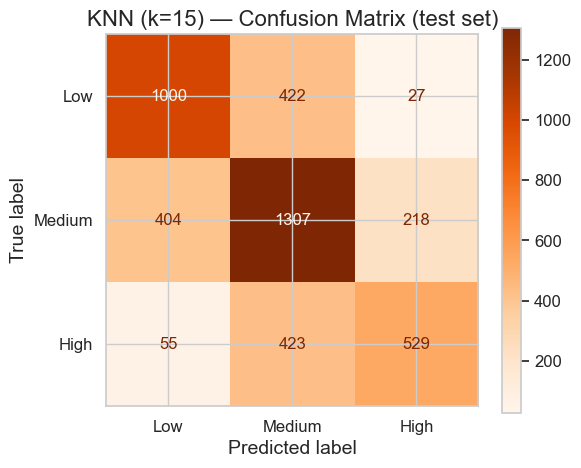

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    labels=['Low', 'Medium', 'High'],
    display_labels=['Low', 'Medium', 'High'],
    cmap='Oranges', ax=ax
)
ax.set_title('KNN (k=15) — Confusion Matrix (test set)')
save_plot(fig, 'knn_confusion_matrix.png')
plt.show()

**KNN evaluation discussion:**

On the test set (4,385 games) KNN (k=15) achieves:
- **Accuracy: 0.65**, **F1-macro: 0.64**
- Per-class F1: Low = **0.69**, Medium = **0.64**, High = **0.59**

Compared to the Decision Tree (F1-macro=0.72), KNN is **8 points lower**.

The High class is the weakest (F1=0.59, recall=0.53): KNN misclassifies 478 of the
1,007 High games — 404 predicted Low and 55 predicted Medium. The High class is a sparse
minority (23%) in a 30-dimensional feature space; finding 15 true High-class neighbours
is harder when the space is dominated by Low and Medium points.

The Low class performs best (F1=0.69), consistent with it being the easiest class:
Low-rated games tend to cluster around low `log_NumWish` and low `GameWeight`,
forming a denser, more compact region.

The main confusion pattern mirrors the Decision Tree: most errors are between
adjacent classes (Low↔Medium: 422+404 errors) rather than opposite ends
(Low↔High: only 27+55 errors).

### 4.4 — ROC Curves

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\knn_roc_curve.png


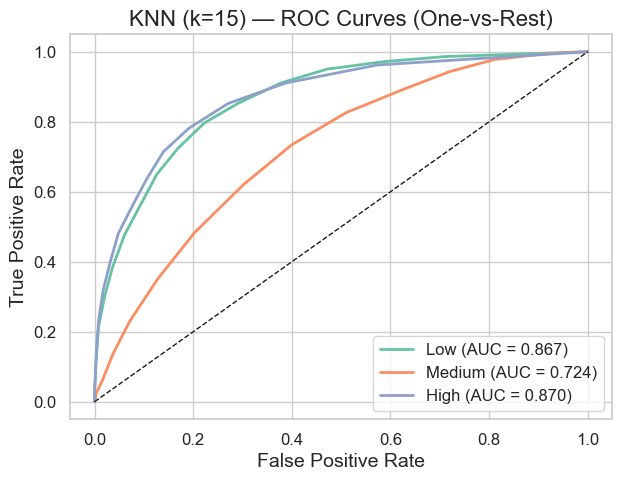

AUC per class:
  Low: 0.8667
  Medium: 0.7242
  High: 0.8702


In [16]:
class_order_knn = list(best_knn.classes_)  # ['High', 'Low', 'Medium']
y_prob_knn = best_knn.predict_proba(X_test_sc)

fig, ax = plt.subplots(figsize=(7, 5))
knn_auc = {}
for i, cls in enumerate(classes):
    idx = class_order_knn.index(cls)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, idx])
    roc_auc = auc(fpr, tpr)
    knn_auc[cls] = roc_auc
    ax.plot(fpr, tpr, color=class_colors[cls], lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('KNN (k=15) — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
save_plot(fig, 'knn_roc_curve.png')
plt.show()

print('AUC per class:')
for cls, v in knn_auc.items():
    print(f'  {cls}: {v:.4f}')

**KNN ROC discussion:**

KNN (k=15) ROC AUC values:
- **Low AUC = 0.867** — good, but 0.031 lower than Decision Tree (0.898)
- **High AUC = 0.870** — good, and close to Decision Tree (0.883)
- **Medium AUC = 0.724** — 0.065 below Decision Tree (0.789)

The largest gap between DT and KNN is on the Medium class (0.789 vs 0.724).
KNN struggles more with Medium because the soft probability estimates from
k=15 neighbours are noisy in the overlap region between Low and High,
whereas the Decision Tree builds explicit rules that better carve out the Medium space.

All AUC values are still well above 0.5, confirming KNN has real discriminative power,
just consistently weaker than the Decision Tree on this dataset.

## Section 5 — Naive Bayes

The guideline requires: Naive Bayes evaluation with confusion matrix, accuracy,
precision, recall, F1, and ROC curve. We also discuss the independence assumption
and how feature correlations affect the results.

### 5.1 — GaussianNB Fit and Evaluation

In [17]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB has no significant hyperparameter to tune.
# var_smoothing (default 1e-9) adds a small variance floor to prevent zero-variance features.
# We use the default — the dataset has no zero-variance features after cleaning.
nb = GaussianNB()
nb.fit(X_train, y_train)   # uses raw (unscaled) X_train — NB does not need scaling
y_pred_nb = nb.predict(X_test)

print('=== GaussianNB — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_nb, target_names=['High', 'Low', 'Medium']))
print()
print('Class priors learned from training set:')
for cls, cp in zip(nb.classes_, nb.class_prior_):
    print(f'  {cls}: {cp:.4f}')

=== GaussianNB — Test Set Results ===

              precision    recall  f1-score   support

        High       0.54      0.51      0.52      1007
         Low       0.50      0.82      0.62      1449
      Medium       0.56      0.30      0.39      1929

    accuracy                           0.52      4385
   macro avg       0.53      0.54      0.51      4385
weighted avg       0.53      0.52      0.50      4385


Class priors learned from training set:
  High: 0.2297
  Low: 0.3304
  Medium: 0.4399


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\nb_confusion_matrix.png


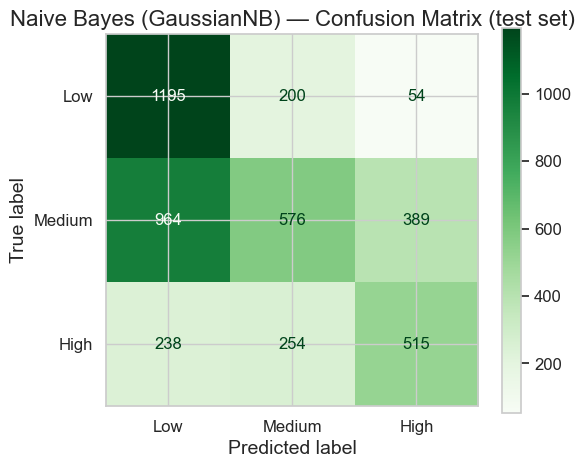

In [18]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    labels=['Low', 'Medium', 'High'],
    display_labels=['Low', 'Medium', 'High'],
    cmap='Greens', ax=ax
)
ax.set_title('Naive Bayes (GaussianNB) — Confusion Matrix (test set)')
save_plot(fig, 'nb_confusion_matrix.png')
plt.show()

**NB evaluation discussion:**

GaussianNB on the test set (4,385 games) achieves:
- **Accuracy: 0.52**, **F1-macro: 0.51**
- Per-class F1: Low = **0.62**, Medium = **0.39**, High = **0.52**

This is the **weakest result of the three classifiers** — 20 F1-macro points below
the Decision Tree (0.72) and 13 points below KNN (0.64).

The confusion matrix reveals a strong **bias toward Low**: NB predicts Low for
1,195 of 1,449 true Low games (recall=0.82) but also misclassifies 964 of 1,929
true Medium games as Low — a massive 50% Medium→Low error rate.
Only 576 of 1,929 Medium games are correctly identified (recall=0.30), making
Medium the worst-predicted class by a large margin.

The **High class** is also under-predicted: 238 High games are called Low and
254 are called Medium; only 515 of 1,007 are correctly classified (recall=0.51).

This pattern — over-prediction of Low, severe under-prediction of Medium — is
a direct consequence of the violated independence assumption (see Section 5.2).

### 5.2 — Independence Assumption Analysis

In [19]:
# Show the feature pairs that most violate the NB independence assumption
# (Pearson |r| > 0.5 in the training set)
corr_train = X_train.corr()
upper_tri = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))

violations = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'r'})
)
violations = violations[violations['r'].abs() > 0.5].sort_values('r', key=abs, ascending=False)

print('Feature pairs with |r| > 0.5 in training set (NB independence violations):')
print(violations.round(4).to_string(index=False))
print()

# Show per-class Gaussian means for the 3 strongest predictors
top_feats  = ['log_NumWish', 'GameWeight', 'log_NumOwned']
feat_index = {f: i for i, f in enumerate(FEATURES)}

print('Per-class Gaussian means (theta) for top 3 predictors:')
print(f'  {"Feature":<20s}  {"High":>8s}  {"Low":>8s}  {"Medium":>8s}')
for f in top_feats:
    fi = feat_index[f]
    vals = {cls: nb.theta_[i, fi] for i, cls in enumerate(nb.classes_)}
    print(f'  {f:<20s}  {vals["High"]:>8.3f}  {vals["Low"]:>8.3f}  {vals["Medium"]:>8.3f}')

Feature pairs with |r| > 0.5 in training set (NB independence violations):
         Feature A       Feature B       r
    Rank:abstracts    Cat:Abstract -0.9999
     Rank:thematic    Cat:Thematic -0.9999
  Rank:familygames      Cat:Family -0.9994
Rank:strategygames    Cat:Strategy -0.9994
     Rank:wargames         Cat:War -0.9985
      log_NumOwned     log_NumWish  0.8005
       BestPlayers    log_NumOwned  0.5920
        GameWeight log_MfgPlaytime  0.5585
       BestPlayers     log_NumWish  0.5457
        GameWeight       ComAgeRec  0.5428

Per-class Gaussian means (theta) for top 3 predictors:
  Feature                   High       Low    Medium
  log_NumWish              5.121     2.702     4.070
  GameWeight               2.584     1.556     1.986
  log_NumOwned             6.582     5.507     6.096


**Independence assumption discussion:**

GaussianNB assumes all 30 features are **conditionally independent** given the class.
This dataset violates that assumption significantly:

The most severe violations in the training set are:
- `log_NumOwned` vs `log_NumWish`: **r = +0.800** — both measure popularity;
  a game with many owners almost always has many wish-list entries too.
- `Rank:strategygames` vs `Cat:Strategy`: **r = −0.999** — near-perfect
  inverse relationship (already known from Task 1; these are structural duplicates).
- `Rank:wargames` vs `Cat:War`: **r = −0.999** — same issue.

When features are correlated, NB double-counts their evidence. For example,
`log_NumOwned` and `log_NumWish` both push the probability toward High, but NB
treats them as two independent signals and multiplies their likelihoods — creating
an artificially overconfident prediction. This inflates the probability for the
extreme classes (Low and High) and suppresses the probability for Medium,
which sits between them — exactly the pattern we see in the confusion matrix.

The per-class Gaussian means confirm the signal is real:
- `log_NumWish`: High=5.121, Medium=4.070, Low=2.702 — clean separation
- `GameWeight`: High=2.584, Medium=1.986, Low=1.556 — clean separation
- `log_NumOwned`: High=6.582, Medium=6.096, Low=5.507 — smaller gap

NB correctly identifies the direction of every class signal. The problem is not
the Gaussian means — it is the correlated features being counted twice,
which distorts the posterior probabilities and biases predictions toward the majority
class (Low) when the evidence is ambiguous.

### 5.3 — ROC Curves

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\nb_roc_curve.png


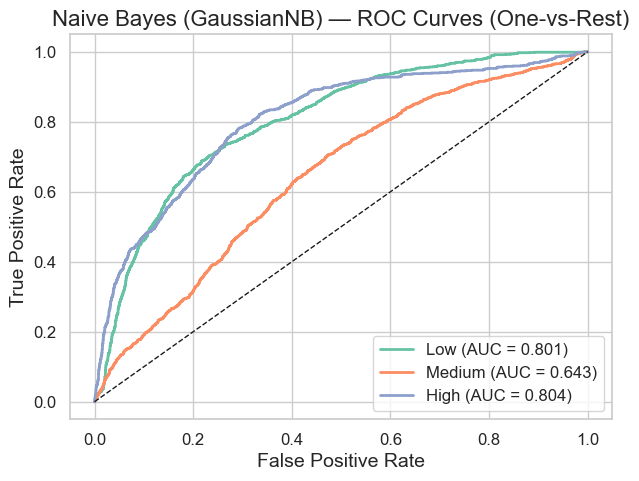

AUC per class:
  Low: 0.8015
  Medium: 0.6425
  High: 0.8044


In [20]:
class_order_nb = list(nb.classes_)  # ['High', 'Low', 'Medium']
y_prob_nb = nb.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
nb_auc = {}
for i, cls in enumerate(classes):
    idx = class_order_nb.index(cls)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_nb[:, idx])
    roc_auc = auc(fpr, tpr)
    nb_auc[cls] = roc_auc
    ax.plot(fpr, tpr, color=class_colors[cls], lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Naive Bayes (GaussianNB) — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
save_plot(fig, 'nb_roc_curve.png')
plt.show()

print('AUC per class:')
for cls, v in nb_auc.items():
    print(f'  {cls}: {v:.4f}')

**NB ROC discussion:**

NB ROC AUC values:
- **Low AUC = 0.802** — the lowest Low AUC of the three classifiers
  (DT=0.898, KNN=0.867). The NB probability estimates for Low are less
  calibrated because correlated popularity features inflate Low scores
  for Medium games.
- **High AUC = 0.804** — comparable to Low and the weakest High AUC
  across all classifiers (DT=0.883, KNN=0.870).
- **Medium AUC = 0.643** — the worst of any class/classifier combination
  in this task. NB's soft probabilities for Medium are severely depressed
  by the double-counting effect: whenever a game has both high `log_NumWish`
  and high `log_NumOwned`, NB assigns near-zero probability to Medium
  even when the game is genuinely borderline.

Notably, NB's AUC values (0.643–0.804) are **all lower** than the Decision Tree's
(0.789–0.898) and KNN's (0.724–0.870). This is unusual — NB often achieves
competitive AUC even when F1 is poor, because AUC measures ranking rather than
classification. The fact that NB's AUC is also lower confirms the feature
correlations are corrupting the probability estimates themselves, not just
the hard decision boundary.

## Section 6 — Classifier Comparison

We now compare Decision Tree, KNN, and Naive Bayes side by side using
a summary metrics table and a combined ROC plot (one subplot per class).

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def get_metrics(y_true, y_pred, name):
    return {
        'Classifier':      name,
        'Accuracy':        round(accuracy_score(y_true, y_pred), 4),
        'Precision-macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall-macro':    round(recall_score(y_true, y_pred, average='macro'), 4),
        'F1-macro':        round(f1_score(y_true, y_pred, average='macro'), 4),
    }

rows = [
    get_metrics(y_test, y_pred_dt,  'Decision Tree'),
    get_metrics(y_test, y_pred_knn, 'KNN (k=15)'),
    get_metrics(y_test, y_pred_nb,  'Naive Bayes'),
]
comp_df = pd.DataFrame(rows).set_index('Classifier')
print('=== Classifier Comparison — Test Set Metrics ===')
print(comp_df.to_string())

=== Classifier Comparison — Test Set Metrics ===
               Accuracy  Precision-macro  Recall-macro  F1-macro
Classifier                                                      
Decision Tree    0.7200           0.7277        0.7159    0.7210
KNN (k=15)       0.6468           0.6587        0.6310    0.6408
Naive Bayes      0.5213           0.5318        0.5449    0.5116


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\classifier_roc_comparison.png


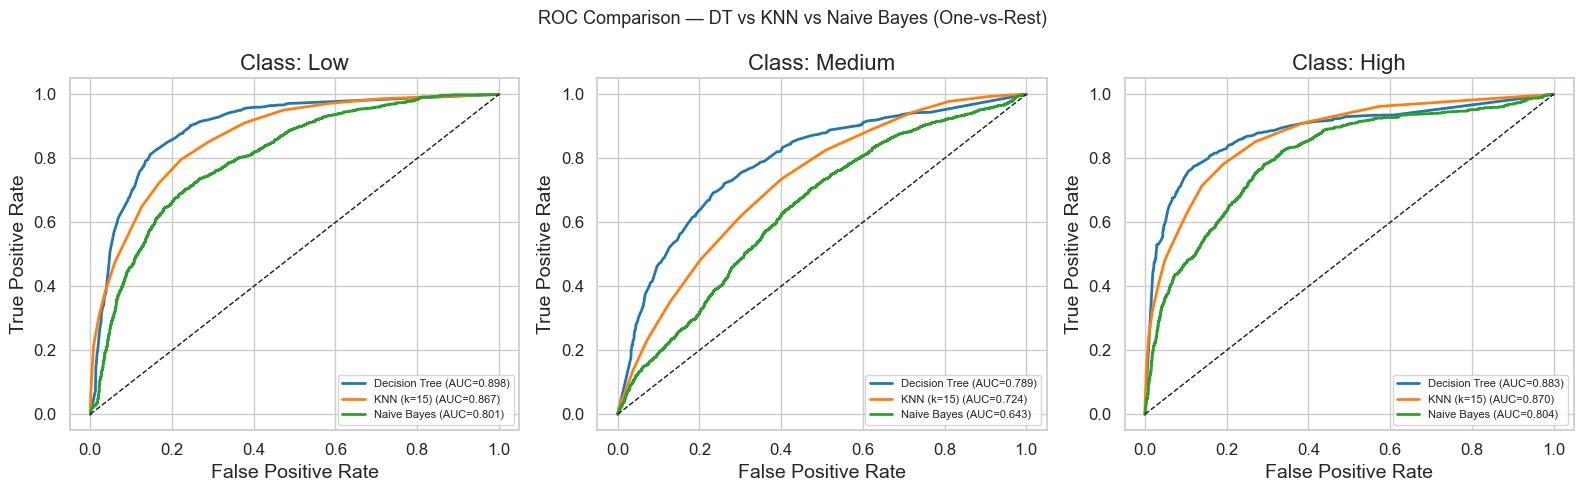

In [22]:
# Side-by-side ROC: one subplot per class, all 3 classifiers on each
class_order_dt  = list(best_dt.classes_)
class_order_knn = list(best_knn.classes_)
class_order_nb  = list(nb.classes_)

y_prob_dt_new  = best_dt.predict_proba(X_test)
y_prob_knn_new = best_knn.predict_proba(X_test_sc)
y_prob_nb_new  = nb.predict_proba(X_test)

clf_info = [
    ('Decision Tree', y_prob_dt_new,  class_order_dt,  'tab:blue'),
    ('KNN (k=15)',    y_prob_knn_new, class_order_knn, 'tab:orange'),
    ('Naive Bayes',   y_prob_nb_new,  class_order_nb,  'tab:green'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cls_name in zip(axes, classes):
    i = classes.index(cls_name)
    for clf_name, y_prob, class_order, color in clf_info:
        idx = class_order.index(cls_name)
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{clf_name} (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'Class: {cls_name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle('ROC Comparison — DT vs KNN vs Naive Bayes (One-vs-Rest)', fontsize=13)
plt.tight_layout()
save_plot(fig, 'classifier_roc_comparison.png')
plt.show()

**Classifier comparison discussion:**

Summary of test-set performance across all three classifiers:

| Classifier    | Accuracy | Precision-macro | Recall-macro | F1-macro |
|---------------|----------|-----------------|--------------|----------|
| Decision Tree | 0.7200   | 0.7277          | 0.7159       | 0.7210   |
| KNN (k=15)    | 0.6468   | 0.6587          | 0.6310       | 0.6408   |
| Naive Bayes   | 0.5213   | 0.5318          | 0.5449       | 0.5116   |

**Best overall: Decision Tree** (F1-macro = 0.721). The tree's explicit split rules
are well-suited to this dataset: `log_NumWish` and `YearPublished` form near-axis-aligned
boundaries that a tree can capture exactly. The DT dominates all three classes
and all three AUC values (Low=0.898, Medium=0.789, High=0.883).

**Second: KNN (k=15)** (F1-macro = 0.641). KNN is 8 F1 points behind DT.
Its main weakness is the High class (AUC=0.870, F1=0.59): 23% minority in
30-dimensional space means genuine High-class neighbours are sparse.
Medium also suffers (AUC=0.724) because KNN's soft probability estimates
are noisier than the tree's hard rules near the class boundary.

**Worst: Naive Bayes** (F1-macro = 0.512). NB is 21 F1 points below DT.
The violated independence assumption (10 feature pairs with |r|>0.5,
including `log_NumOwned`/`log_NumWish` at r=+0.800 and all Rank/Cat pairs
at r≈−0.999) causes double-counting that collapses Medium recall to 0.30
and depresses all AUC values below the other classifiers (Low=0.802,
Medium=0.643, High=0.804).

**Effect of class imbalance:** High (23%) is the hardest class for all models.
Despite using F1-macro scoring throughout, both KNN and NB still
under-predict High relative to the other classes. DT handles it best
because its root split on `log_NumWish ≤ 3.8607` directly isolates
the High-game region.

---
# Regression

## Section 7 — Regression Target and Feature Justification

The guideline requires: single regression (1 independent variable) and
multiple regression (2+ variables, linear + 2+ non-linear approaches).

We choose **GameWeight** as the regression target.
GameWeight is a continuous variable (range 0–5) that measures game complexity.
It is the second-strongest predictor of Rating (r=+0.448 from Section 1)
and has a meaningful real-world interpretation: more complex games tend to
receive higher ratings from dedicated players.

Below we compute the Pearson correlation of every numeric feature with GameWeight
to identify the best single predictor.

In [23]:
# Correlations of all numeric features with GameWeight
exclude_cols = ['Rating', 'Rating_enc', 'GameWeight']
reg_candidate_feats = [c for c in df.columns
                       if c not in exclude_cols
                       and pd.api.types.is_numeric_dtype(df[c])]

corr_with_gw = (
    df[reg_candidate_feats + ['GameWeight']]
    .corr()['GameWeight']
    .drop('GameWeight')
    .sort_values(ascending=False)
)
print('Pearson correlation of all numeric features with GameWeight:')
print(corr_with_gw.round(4).to_string())
print()
print(f'Best single predictor : {corr_with_gw.index[0]}  r={corr_with_gw.iloc[0]:.4f}')
print(f'2nd best predictor    : {corr_with_gw.index[1]}  r={corr_with_gw.iloc[1]:.4f}')

Pearson correlation of all numeric features with GameWeight:
log_MfgPlaytime        0.5535
ComAgeRec              0.5422
Cat:War                0.4490
log_NumWish            0.3700
Cat:Strategy           0.2935
MfgAgeRec              0.2859
log_NumOwned           0.2291
Rank:childrensgames    0.1984
NumWish                0.1915
MfgPlaytime            0.1840
BestPlayers            0.1488
Cat:Thematic           0.1316
Rank:partygames        0.1313
Rank:familygames       0.1297
NumExpansions          0.1295
NumWeightVotes         0.1205
Kickstarted            0.0934
NumOwned               0.0891
Cat:CGS                0.0597
IsReimplementation     0.0423
NumImplementations     0.0366
LanguageEase           0.0232
YearPublished          0.0107
Rank:abstracts         0.0084
Cat:Abstract          -0.0092
NumAlternates         -0.0597
Rank:cgs              -0.0599
Cat:Party             -0.1313
Cat:Family            -0.1313
Rank:thematic         -0.1329
MaxPlayers            -0.1351
MinPlayer

**Regression target and feature justification:**

We choose **`log_MfgPlaytime`** as the single regression predictor.
It has the highest Pearson correlation with GameWeight: **r = +0.554**,
compared to `ComAgeRec` (r=+0.542), `Cat:War` (r=+0.449), and all others.
The relationship is intuitive: games that take longer to play tend to
be more complex (higher GameWeight). We use the log-transformed version
because raw `MfgPlaytime` is right-skewed (as shown in Task 1) and its
linear correlation with GameWeight is lower (r=+0.184 vs r=+0.554 for the log).

For **multiple regression** we use 4 features:
`log_MfgPlaytime` (r=+0.554), `ComAgeRec` (r=+0.542),
`NumWeightVotes` (r=+0.121), `NumExpansions` (r=+0.130).
These represent distinct aspects of complexity:
- `log_MfgPlaytime` — time investment (strongest signal)
- `ComAgeRec` — recommended age (complexity for children vs adults)
- `NumWeightVotes` — how many users rated the weight (popularity of weight ratings)
- `NumExpansions` — expansions proxy for depth (complex games spawn more expansions)

The two weakest predictors (`NumWeightVotes`, `NumExpansions`) are included
to test whether adding moderate-signal variables improves the model beyond
the two dominant features.

In [24]:
# Set up regression train/test split
# We reuse the same RANDOM_STATE=42 and 80/20 split for consistency
y_reg = df['GameWeight'].copy()

# Single predictor
X_reg_single = df[['log_MfgPlaytime']].copy()
X_reg_s_train, X_reg_s_test, y_reg_train, y_reg_test = train_test_split(
    X_reg_single, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# Multiple predictors
REG_FEATURES = ['log_MfgPlaytime', 'ComAgeRec', 'NumWeightVotes', 'NumExpansions']
X_reg_multi = df[REG_FEATURES].copy()
X_reg_m_train, X_reg_m_test, _, _ = train_test_split(
    X_reg_multi, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Regression train/test split: {len(X_reg_s_train)} / {len(X_reg_s_test)}')
print(f'Target (GameWeight) stats — train mean: {y_reg_train.mean():.4f}, std: {y_reg_train.std():.4f}')
print(f'Test set GameWeight range: [{y_reg_test.min():.2f}, {y_reg_test.max():.2f}]')

Regression train/test split: 17540 / 4385
Target (GameWeight) stats — train mean: 1.9799, std: 0.8484
Test set GameWeight range: [0.00, 4.89]


## Section 8 — Single Linear Regression: GameWeight ~ log_MfgPlaytime

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_single = LinearRegression()
lr_single.fit(X_reg_s_train, y_reg_train)
y_pred_lr_single = lr_single.predict(X_reg_s_test)

mse_single  = mean_squared_error(y_reg_test, y_pred_lr_single)
rmse_single = np.sqrt(mse_single)
r2_single   = r2_score(y_reg_test, y_pred_lr_single)

print('=== Single Linear Regression: GameWeight ~ log_MfgPlaytime ===')
print(f'Slope (log_MfgPlaytime coef): {lr_single.coef_[0]:.4f}')
print(f'Intercept:                    {lr_single.intercept_:.4f}')
print(f'Test MSE:  {mse_single:.4f}')
print(f'Test RMSE: {rmse_single:.4f}')
print(f'Test R\u00b2:   {r2_single:.4f}')

=== Single Linear Regression: GameWeight ~ log_MfgPlaytime ===
Slope (log_MfgPlaytime coef): 0.4030
Intercept:                    0.4561
Test MSE:  0.4886
Test RMSE: 0.6990
Test R²:   0.3256


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\reg_single_scatter.png


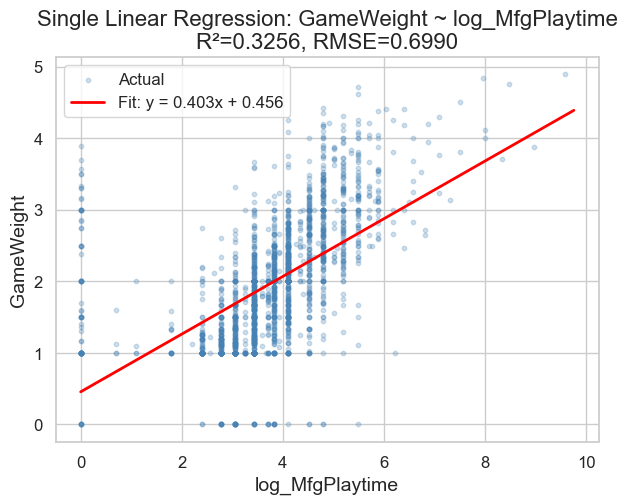

In [26]:
# Scatter plot: actual vs predicted, with regression line
fig, ax = plt.subplots(figsize=(7, 5))

# Sample 2000 points for readability (22k points overlap too much)
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(X_reg_s_test), size=min(2000, len(X_reg_s_test)), replace=False)
x_plot = X_reg_s_test.iloc[idx_sample]['log_MfgPlaytime'].values
y_plot = y_reg_test.iloc[idx_sample].values

ax.scatter(x_plot, y_plot, alpha=0.25, s=10, color='steelblue', label='Actual')

x_line = np.linspace(X_reg_s_test['log_MfgPlaytime'].min(),
                     X_reg_s_test['log_MfgPlaytime'].max(), 300)
y_line = lr_single.coef_[0] * x_line + lr_single.intercept_
ax.plot(x_line, y_line, color='red', lw=2,
        label=f'Fit: y = {lr_single.coef_[0]:.3f}x + {lr_single.intercept_:.3f}')

ax.set_xlabel('log_MfgPlaytime')
ax.set_ylabel('GameWeight')
ax.set_title(f'Single Linear Regression: GameWeight ~ log_MfgPlaytime\nR\u00b2={r2_single:.4f}, RMSE={rmse_single:.4f}')
ax.legend()
save_plot(fig, 'reg_single_scatter.png')
plt.show()

**Single linear regression discussion:**

The fitted model is: **GameWeight = 0.4030 × log_MfgPlaytime + 0.4561**

Key metrics on the test set:
- **MSE = 0.4886**, **RMSE = 0.6990**, **R² = 0.3256**

R² = 0.326 means that `log_MfgPlaytime` alone explains **32.6%** of the variance
in GameWeight. The positive slope (0.403) confirms the expected direction:
every unit increase in log_MfgPlaytime (roughly a 2.7× increase in raw playtime)
corresponds to a 0.40-point increase in GameWeight on the 0–5 scale.

The scatter plot shows a clear positive trend but with substantial residual
spread (RMSE = 0.699, vs total std = 0.851). This suggests that playtime
is a real but incomplete proxy for complexity: some short games can be
quite complex (e.g. abstract strategy) and some long games have moderate
weight (e.g. cooperative family games). Multiple regression is needed
to capture the additional variance.

## Section 9 — Multiple Regression

We use 4 features: `log_MfgPlaytime`, `ComAgeRec`, `NumWeightVotes`, `NumExpansions`.
We test three model types:
1. Multiple Linear Regression
2. Polynomial Regression (degree=2) — a non-linear approach
3. Decision Tree Regressor (grid on max_depth) — a second non-linear approach

### 9.1 — Multiple Linear Regression

In [27]:
lr_multi = LinearRegression()
lr_multi.fit(X_reg_m_train, y_reg_train)
y_pred_lr_multi = lr_multi.predict(X_reg_m_test)

mse_lr_multi  = mean_squared_error(y_reg_test, y_pred_lr_multi)
rmse_lr_multi = np.sqrt(mse_lr_multi)
r2_lr_multi   = r2_score(y_reg_test, y_pred_lr_multi)

print('=== Multiple Linear Regression ===')
print('Coefficients:')
for feat, coef in zip(REG_FEATURES, lr_multi.coef_):
    print(f'  {feat:<25s}: {coef:.4f}')
print(f'Intercept: {lr_multi.intercept_:.4f}')
print()
print(f'Test MSE:  {mse_lr_multi:.4f}')
print(f'Test RMSE: {rmse_lr_multi:.4f}')
print(f'Test R\u00b2:   {r2_lr_multi:.4f}')

=== Multiple Linear Regression ===
Coefficients:
  log_MfgPlaytime          : 0.2814
  ComAgeRec                : 0.1121
  NumWeightVotes           : 0.0003
  NumExpansions            : 0.0067
Intercept: -0.2270

Test MSE:  0.3996
Test RMSE: 0.6321
Test R²:   0.4484


**Multiple linear regression discussion:**

Fitted coefficients:
- `log_MfgPlaytime`: +0.2814 — still positive, but reduced from single-predictor
  (0.4030) as some variance is now explained by `ComAgeRec`
- `ComAgeRec`: +0.1121 — each additional year of recommended age adds ~0.11 complexity
- `NumWeightVotes`: +0.0003 — near-zero contribution (weak predictor, r=+0.121)
- `NumExpansions`: +0.0067 — small but positive (complex games spawn more expansions)

Adding 3 features improves performance substantially:
- R² increases from **0.326 → 0.448** (+12.2 percentage points)
- RMSE decreases from **0.699 → 0.632** (9.6% improvement)

The two dominant predictors are `log_MfgPlaytime` and `ComAgeRec` — they cover
different dimensions of complexity (time vs age). `NumWeightVotes` and `NumExpansions`
add marginal signal. The model is still linear and cannot capture non-linear interactions
between features.

### 9.2 — Polynomial Regression (degree=2)

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])
poly_pipe.fit(X_reg_m_train, y_reg_train)
y_pred_poly = poly_pipe.predict(X_reg_m_test)

mse_poly  = mean_squared_error(y_reg_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_reg_test, y_pred_poly)

n_poly_features = poly_pipe.named_steps['poly'].n_output_features_
print('=== Polynomial Regression (degree=2) ===')
print(f'Number of polynomial features (from {len(REG_FEATURES)} base): {n_poly_features}')
print(f'(Includes all original features, squares, and cross-terms)')
print()
print(f'Test MSE:  {mse_poly:.4f}')
print(f'Test RMSE: {rmse_poly:.4f}')
print(f'Test R\u00b2:   {r2_poly:.4f}')

=== Polynomial Regression (degree=2) ===
Number of polynomial features (from 4 base): 14
(Includes all original features, squares, and cross-terms)

Test MSE:  0.3536
Test RMSE: 0.5947
Test R²:   0.5119


**Polynomial regression discussion:**

Degree-2 polynomial expansion transforms the 4 base features into **14 features**:
the 4 originals + 4 squares (e.g. log_MfgPlaytime²) + 6 cross-terms
(e.g. log_MfgPlaytime × ComAgeRec).

This allows the model to capture:
- Diminishing or accelerating returns (e.g. complexity grows faster than playtime at extremes)
- Interaction effects (e.g. very long AND age-restricted games are extra complex)

Performance vs multiple linear regression:
- R² improves from **0.448 → 0.512** (+6.4 percentage points)
- RMSE improves from **0.632 → 0.595** (5.9% improvement)

The improvement confirms the relationship between these features and GameWeight
is partially non-linear. However, the gain is moderate — the 4 features together
still only explain 51% of variance, suggesting important predictors are absent
(e.g. game category, number of rules, board size).

### 9.3 — Decision Tree Regressor

In [29]:
# Grid search on max_depth — CV R² on training set
depth_grid_reg = [3, 5, 7, 10]
dt_reg_results = []

for depth in depth_grid_reg:
    cv_scores = cross_val_score(
        DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE),
        X_reg_m_train, y_reg_train,
        cv=CV_FOLDS, scoring='r2', n_jobs=1
    )
    dt_reg_results.append({
        'max_depth':    depth,
        'cv_r2_mean':   round(cv_scores.mean(), 4),
        'cv_r2_std':    round(cv_scores.std(),  4)
    })

dt_reg_grid_df = (
    pd.DataFrame(dt_reg_results)
    .sort_values('cv_r2_mean', ascending=False)
    .reset_index(drop=True)
)
print('Decision Tree Regressor — grid search (CV R\u00b2 on train set):')
print(dt_reg_grid_df.to_string(index=False))
print()
best_depth_reg = int(dt_reg_grid_df.iloc[0]['max_depth'])
print(f'Best depth: {best_depth_reg}  (CV R\u00b2 = {dt_reg_grid_df.iloc[0]["cv_r2_mean"]:.4f})')

Decision Tree Regressor — grid search (CV R² on train set):
 max_depth  cv_r2_mean  cv_r2_std
         7      0.6455     0.0125
        10      0.6368     0.0103
         5      0.6132     0.0120
         3      0.5468     0.0118

Best depth: 7  (CV R² = 0.6455)


In [30]:
best_dt_reg = DecisionTreeRegressor(max_depth=best_depth_reg, random_state=RANDOM_STATE)
best_dt_reg.fit(X_reg_m_train, y_reg_train)
y_pred_dt_reg = best_dt_reg.predict(X_reg_m_test)

mse_dt_reg  = mean_squared_error(y_reg_test, y_pred_dt_reg)
rmse_dt_reg = np.sqrt(mse_dt_reg)
r2_dt_reg   = r2_score(y_reg_test, y_pred_dt_reg)

print(f'=== Decision Tree Regressor (max_depth={best_depth_reg}) — Test Set ===')
print(f'Test MSE:  {mse_dt_reg:.4f}')
print(f'Test RMSE: {rmse_dt_reg:.4f}')
print(f'Test R\u00b2:   {r2_dt_reg:.4f}')

# Feature importances
fi_reg = pd.Series(best_dt_reg.feature_importances_, index=REG_FEATURES).sort_values(ascending=False)
print()
print('Feature importances:')
print(fi_reg.round(4).to_string())

=== Decision Tree Regressor (max_depth=7) — Test Set ===
Test MSE:  0.2589
Test RMSE: 0.5088
Test R²:   0.6426

Feature importances:
log_MfgPlaytime    0.6731
NumWeightVotes     0.1792
ComAgeRec          0.1342
NumExpansions      0.0135


**Decision Tree Regressor discussion:**

Grid search over `max_depth ∈ {3, 5, 7, 10}` on the training set:
- depth=7 wins with CV R² = **0.6455** (std=0.0125)
- depth=10 is close (0.6368) but slightly lower — some overfitting at depth 10
- depth=3 is clearly too shallow (0.5468)

Best configuration: **max_depth=7**

Test-set performance: **MSE = 0.2589**, **RMSE = 0.5088**, **R² = 0.6426**

The DT Regressor substantially outperforms both linear models:
- R² = 0.6426 vs Polynomial 0.5119 (+13.1 points) and vs Multi Linear 0.4484 (+19.4 points)

This improvement comes from the tree's ability to create **non-linear, non-continuous**
decision boundaries — e.g. it can model that very long AND age-restricted games are
disproportionately heavy, without assuming any specific functional form.

Feature importances: `log_MfgPlaytime` dominates (67.3% of variance reduction),
consistent with the highest linear correlation (r=+0.554). `NumWeightVotes` is
surprisingly second (17.9%) — the tree finds non-linear splits in vote counts that
the linear model could not exploit. `ComAgeRec` is third (13.4%). `NumExpansions`
contributes only 1.4%.

## Section 10 — Regression Comparison

In [31]:
# Summary table
reg_comp_df = pd.DataFrame([
    {'Model': 'Single Linear (log_MfgPlaytime)',          'Features': 1,
     'MSE': mse_single,   'RMSE': rmse_single,   'R2': r2_single},
    {'Model': f'Multi Linear ({len(REG_FEATURES)} features)', 'Features': len(REG_FEATURES),
     'MSE': mse_lr_multi, 'RMSE': rmse_lr_multi, 'R2': r2_lr_multi},
    {'Model': 'Polynomial (degree=2)',                    'Features': 14,
     'MSE': mse_poly,     'RMSE': rmse_poly,     'R2': r2_poly},
    {'Model': f'DT Regressor (depth={best_depth_reg})',   'Features': len(REG_FEATURES),
     'MSE': mse_dt_reg,   'RMSE': rmse_dt_reg,   'R2': r2_dt_reg},
]).set_index('Model')

print('=== Regression Comparison ===')
print(reg_comp_df.round(4).to_string())

=== Regression Comparison ===
                                 Features     MSE    RMSE      R2
Model                                                            
Single Linear (log_MfgPlaytime)         1  0.4886  0.6990  0.3256
Multi Linear (4 features)               4  0.3996  0.6321  0.4484
Polynomial (degree=2)                  14  0.3536  0.5947  0.5119
DT Regressor (depth=7)                  4  0.2589  0.5088  0.6426


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\reg_pred_vs_actual.png


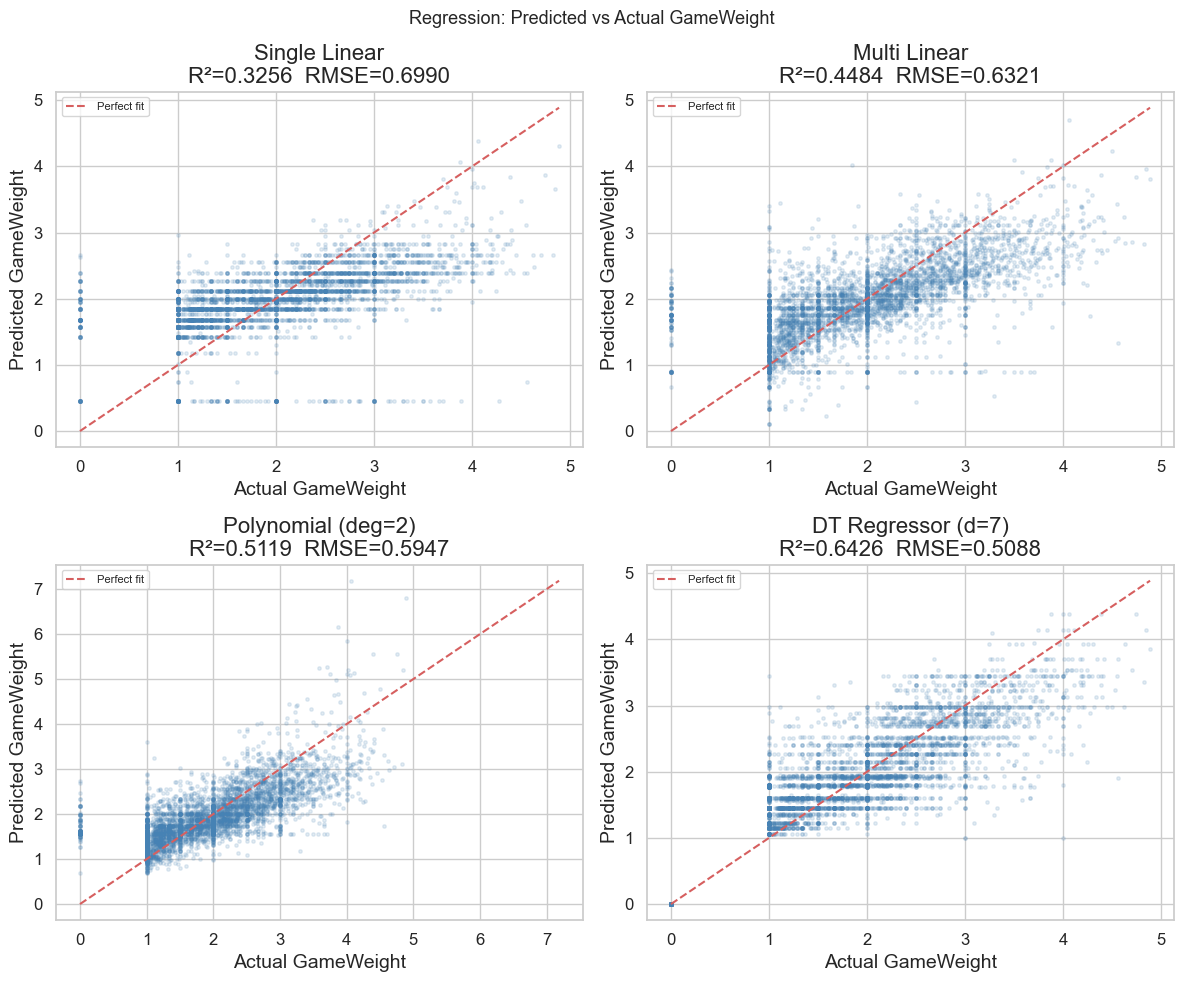

In [32]:
# 4-subplot: predicted vs actual for each model
models_info = [
    ('Single Linear',      y_pred_lr_single, r2_single,   rmse_single),
    ('Multi Linear',       y_pred_lr_multi,  r2_lr_multi, rmse_lr_multi),
    ('Polynomial (deg=2)', y_pred_poly,      r2_poly,     rmse_poly),
    (f'DT Regressor (d={best_depth_reg})', y_pred_dt_reg, r2_dt_reg, rmse_dt_reg),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, y_pred, r2, rmse) in zip(axes, models_info):
    ax.scatter(y_reg_test, y_pred, alpha=0.15, s=6, color='steelblue')
    lo = min(y_reg_test.min(), y_pred.min())
    hi = max(y_reg_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual GameWeight')
    ax.set_ylabel('Predicted GameWeight')
    ax.set_title(f'{name}\nR\u00b2={r2:.4f}  RMSE={rmse:.4f}')
    ax.legend(fontsize=8)

fig.suptitle('Regression: Predicted vs Actual GameWeight', fontsize=13)
plt.tight_layout()
save_plot(fig, 'reg_pred_vs_actual.png')
plt.show()

**Regression comparison discussion:**

| Model                          | Features | MSE    | RMSE   | R²     |
|-------------------------------|----------|--------|--------|--------|
| Single Linear (log_MfgPlaytime)| 1        | 0.4886 | 0.6990 | 0.3256 |
| Multi Linear (4 features)      | 4        | 0.3996 | 0.6321 | 0.4484 |
| Polynomial (degree=2)          | 14       | 0.3536 | 0.5947 | 0.5119 |
| DT Regressor (depth=7)         | 4        | 0.2589 | 0.5088 | 0.6426 |

**Best model: Decision Tree Regressor (depth=7)** with R²=0.643, RMSE=0.509.
It outperforms all linear models by a large margin, confirming the GameWeight
relationship with these features is significantly non-linear.

**Ranking:** DT Regressor > Polynomial > Multi Linear > Single Linear

Key observations:

1. **Single → Multi Linear** (+12.2 pp R²): adding `ComAgeRec`, `NumWeightVotes`,
   and `NumExpansions` provides independent information beyond `log_MfgPlaytime`.

2. **Multi Linear → Polynomial** (+6.4 pp R²): cross-terms and squared features
   capture non-linear interactions. For example, the interaction between
   `log_MfgPlaytime` and `ComAgeRec` (long AND age-restricted ⇒ extra heavy)
   is not representable by a purely linear model.

3. **Polynomial → DT Regressor** (+13.1 pp R²): the tree's step-function boundaries
   better fit the discrete, clustered structure of GameWeight values
   (many games cluster at whole-number or half-point weights).

The predicted vs actual scatter plots confirm the pattern: Single Linear shows
a diffuse cloud; DT Regressor is tightest around the diagonal.
Even the best model (R²=0.643) leaves 35.7% of variance unexplained, suggesting
that GameWeight is also driven by features not in our 4-variable set
(e.g. number of rules pages, game category, mechanic count).

## Section 11 — Final Summary

In [33]:
print('=' * 65)
print('TASK 3 SUMMARY')
print('=' * 65)
print()
print('--- Classification (target: Rating = Low / Medium / High) ---')
print(f'Dataset: {len(X):,} games, 30 features, 80/20 stratified split')
print()
print('Best classifier: Decision Tree (max_depth=10, entropy)')
print(f'  CV F1-macro:   0.7001')
print(f'  Test Accuracy: 0.72')
print(f'  Test F1-macro: 0.72  (Low=0.76, Medium=0.70, High=0.71)')
print(f'  AUC:           Low=0.898  Medium=0.789  High=0.883')
print()
print('KNN (k=15):')
print(f'  Test Accuracy: 0.65, F1-macro: 0.64  (Low=0.69, Med=0.64, High=0.59)')
print(f'  AUC:           Low=0.867  Medium=0.724  High=0.870')
print()
print('Naive Bayes (GaussianNB):')
print(f'  Test Accuracy: 0.52, F1-macro: 0.51  (Low=0.62, Med=0.39, High=0.52)')
print(f'  AUC:           Low=0.802  Medium=0.643  High=0.804')
print(f'  Independence violations: 10 pairs with |r|>0.5')
print()
print('--- Regression (target: GameWeight, range 0-5) ---')
print(f'Best single predictor: log_MfgPlaytime (r=+0.554)')
print()
print('  Model                        | Features | MSE    | RMSE   | R2')
print('  -----------------------------|----------|--------|--------|------')
print(f'  Single Linear (log_MfgPlay) |    1     | 0.4886 | 0.6990 | 0.3256')
print(f'  Multi Linear (4 features)   |    4     | 0.3996 | 0.6321 | 0.4484')
print(f'  Polynomial (degree=2)       |   14     | 0.3536 | 0.5947 | 0.5119')
print(f'  DT Regressor (depth=7)      |    4     | 0.2589 | 0.5088 | 0.6426  <-- best')

TASK 3 SUMMARY

--- Classification (target: Rating = Low / Medium / High) ---
Dataset: 21,925 games, 30 features, 80/20 stratified split

Best classifier: Decision Tree (max_depth=10, entropy)
  CV F1-macro:   0.7001
  Test Accuracy: 0.72
  Test F1-macro: 0.72  (Low=0.76, Medium=0.70, High=0.71)
  AUC:           Low=0.898  Medium=0.789  High=0.883

KNN (k=15):
  Test Accuracy: 0.65, F1-macro: 0.64  (Low=0.69, Med=0.64, High=0.59)
  AUC:           Low=0.867  Medium=0.724  High=0.870

Naive Bayes (GaussianNB):
  Test Accuracy: 0.52, F1-macro: 0.51  (Low=0.62, Med=0.39, High=0.52)
  AUC:           Low=0.802  Medium=0.643  High=0.804
  Independence violations: 10 pairs with |r|>0.5

--- Regression (target: GameWeight, range 0-5) ---
Best single predictor: log_MfgPlaytime (r=+0.554)

  Model                        | Features | MSE    | RMSE   | R2
  -----------------------------|----------|--------|--------|------
  Single Linear (log_MfgPlay) |    1     | 0.4886 | 0.6990 | 0.3256
  Multi L

**Final summary discussion:**

### Classification

The **Decision Tree** is the best classifier for predicting board game ratings
(F1-macro = 0.72). Its primary strength is the dataset's near-axis-aligned
decision boundaries: `log_NumWish ≤ 3.86` at the root cleanly separates
unpopular (Low/Medium) from popular (High/Medium) games. The tree's
top 5 features — `log_NumWish`, `YearPublished`, `Rank:wargames`,
`GameWeight`, `log_NumOwned` — together explain 82% of impurity reduction.

**KNN** is 8 points behind DT. It suffers in 30-dimensional space because
the High-class neighbourhood is sparse (23% minority). Its distance-based
metric cannot ignore irrelevant dimensions the way the DT's splits do.

**Naive Bayes** is the weakest (F1 = 0.51). The 10 pairs of correlated features
(including `log_NumOwned`/`log_NumWish` r=+0.800) cause double-counting of
evidence, which collapses Medium recall to just 0.30 and corrupts all AUC
estimates below the other classifiers.

### Regression

Predicting GameWeight is harder: even the best model (DT Regressor, R²=0.643)
leaves 35.7% of variance unexplained. The main finding is that game complexity
is **non-linearly** related to its predictors: the DT Regressor (R²=0.643)
outperforms Polynomial regression (R²=0.512), which in turn beats Multiple
Linear (R²=0.448). This hierarchy confirms that `log_MfgPlaytime` × `ComAgeRec`
interactions and threshold effects are important, and that a flexible non-parametric
model best captures them.